In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import Margins

rng = np.random.default_rng(42)
n = 5000
female = rng.binomial(1, 0.52, n)
black = rng.binomial(1, 0.11, n)
age = rng.integers(20, 75, n)
agegrp = pd.cut(
    age, bins=[19, 29, 39, 49, 59, 69, 100], labels=[1, 2, 3, 4, 5, 6]
).astype(int)
bmi = np.clip(22 + 0.15 * age + 1.5 * female + rng.normal(0, 4, n), 15, 50)
lp = (
    -4.0
    + 0.55 * black
    + 0.10 * female
    + 0.06 * age
    + 0.03 * bmi
    + 0.5 * (agegrp == 2)
    + 0.9 * (agegrp == 3)
    + 1.4 * (agegrp == 4)
    + 2.0 * (agegrp == 5)
    + 2.6 * (agegrp == 6)
)
df = pd.DataFrame(
    {
        "diabetes": rng.binomial(1, 1 / (1 + np.exp(-lp))),
        "black": black,
        "female": female,
        "age": age,
        "agegrp": agegrp,
        "bmi": bmi,
    }
)

fit = smf.glm(
    "diabetes ~ C(black) + C(female) + C(agegrp) + bmi + age",
    data=df,
    family=sm.families.Binomial(),
).fit()

In [2]:
print(
    Margins.linear_scale(fit, at="typical")
    .predict(atexog={"agegrp": list(range(1, 7))})
    .summary()
)

            Margins Result (simulation, level=0.95)            
          estimate  std err  statistic  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------
agegrp=1    0.5121   0.0737     0.5121  0.000    0.3639, 0.6546
agegrp=2    0.5950   0.0431     0.5950  0.000    0.5086, 0.6766
agegrp=3    0.6575   0.0189     0.6575  0.000    0.6183, 0.6941
agegrp=4    0.7388   0.0261     0.7388  0.000    0.6847, 0.7866
agegrp=5    0.8062   0.0416     0.8062  0.000    0.7119, 0.8735
agegrp=6    0.9566   0.0362     0.9566  0.000    0.8529, 0.9881

n = 5000
WARNING — Fallback triggered: kappa=0.607>threshold=0.3
κ: max=0.607


/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:704: UserWarning: Delta-method curvature κ=0.607 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


In [3]:
print(
    Margins.linear_scale(fit, at="overall")
    .predict(atexog={"agegrp": list(range(1, 7))})
    .summary()
)

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:704: UserWarning: Delta-method curvature κ=0.531 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


            Margins Result (simulation, level=0.95)            
          estimate  std err  statistic  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------
agegrp=1    0.5152   0.0551     0.5152  0.000    0.3919, 0.6100
agegrp=2    0.5770   0.0273     0.5770  0.000    0.5164, 0.6210
agegrp=3    0.6251   0.0123     0.6251  0.000    0.6012, 0.6487
agegrp=4    0.6915   0.0317     0.6915  0.000    0.6312, 0.7541
agegrp=5    0.7521   0.0508     0.7521  0.000    0.6483, 0.8464
agegrp=6    0.9272   0.0513     0.9272  0.000    0.7903, 0.9822

n = 5000
WARNING — Fallback triggered: kappa=0.531>threshold=0.3
κ: max=0.531


In [4]:
print(
    Margins.linear_scale(fit, at="typical")
    .predict(atexog={"age": [20, 50, 70]})
    .summary()
)

             Margins Result (delta, level=0.95)            
        estimate  std err        z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
age=20    0.2079   0.0539   3.8549  0.000    0.1022, 0.3136
age=50    0.7054   0.0221  31.9227  0.000    0.6621, 0.7487
age=70    0.9127   0.0272  33.5007  0.000    0.8593, 0.9661

n = 5000
κ: max=0.282
Delta-vs-sim disagreement: 10.421%


In [5]:
Margins.linear_scale(fit, at="typical").dydx("age").summary()
print(Margins.linear_scale(fit, at="overall").dydx("age").summary())

           Margins Result (delta, level=0.95)          
     estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------
age    0.0106   0.0025  4.2317  0.000    0.0057, 0.0155

n = 5000
κ: 0.015
Delta-vs-sim disagreement: 12.918%


In [6]:
from pymargins import pairwise

scen, w = pairwise("black", [1, 0])
print(
    Margins.linear_scale(fit, at="overall")
    .contrasts(scenarios=scen, contrasts=w)
    .summary()
)

             Margins Result (delta, level=0.95)            
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
black=1    0.0870   0.0167  5.1965  0.000    0.0542, 0.1198

n = 5000
κ: 0.027
Delta-vs-sim disagreement: 2.040%


/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:704: UserWarning: Delta-method curvature κ=0.531 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


[Text(0.5, 0, 'Age group'), Text(0, 0.5, 'P(diabetes=1)')]

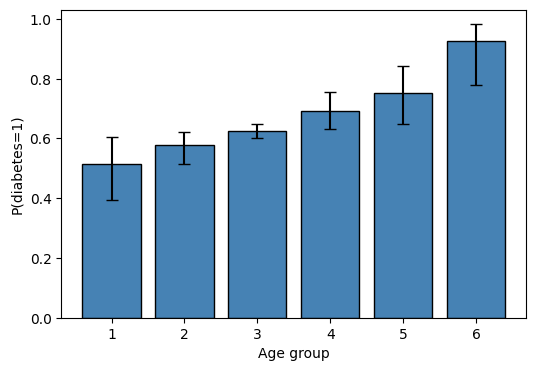

In [7]:
import matplotlib.pyplot as plt

res = Margins.linear_scale(fit, at="overall").predict(
    atexog={"agegrp": list(range(1, 7))}
)
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    df_plot["agegrp"].astype(str),
    df_plot["estimate"],
    yerr=[
        df_plot["estimate"] - df_plot["ci_lower"],
        df_plot["ci_upper"] - df_plot["estimate"],
    ],
    capsize=4,
    color="steelblue",
    edgecolor="black",
)
ax.set(xlabel="Age group", ylabel="P(diabetes=1)")

In [8]:
print(Margins.linear_scale(fit, vcov="HC3", at="overall").dydx("age").summary())

           Margins Result (delta, level=0.95)          
     estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------
age    0.0106   0.0025  4.2620  0.000    0.0057, 0.0155

n = 5000
κ: 0.015
Delta-vs-sim disagreement: 13.485%
